In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import copy

# -------------------------
# Attention Module (CBAM)
# -------------------------
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv1(x)
        return self.sigmoid(x)


class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.ca = ChannelAttention(in_planes, ratio)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x):
        out = x * self.ca(x)
        out = out * self.sa(out)
        return out


# -------------------------
# VGG16 + CBAM
# -------------------------
class VGG16_CBAM(nn.Module):
    def __init__(self, num_classes):
        super(VGG16_CBAM, self).__init__()
        vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.features = vgg16.features

        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)
        self.cbam5 = CBAM(512)

        self.avgpool = vgg16.avgpool
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features[0:5](x); x = self.cbam1(x)
        x = self.features[5:10](x); x = self.cbam2(x)
        x = self.features[10:17](x); x = self.cbam3(x)
        x = self.features[17:24](x); x = self.cbam4(x)
        x = self.features[24:31](x); x = self.cbam5(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# -------------------------
# Dataset & Dataloaders
# -------------------------
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG expects 224x224
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],  # ImageNet mean
                         [0.229, 0.224, 0.225])  # ImageNet std
])

dataset = datasets.ImageFolder(root="balanced_dataset", transform=data_transforms)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

num_classes = len(dataset.classes)
print("Classes:", dataset.classes)


# -------------------------
# Training
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16_CBAM(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

num_epochs = 10
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    scheduler.step(val_acc)

    # Track best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    # Print current LR
    for param_group in optimizer.param_groups:
        print("Current LR:", param_group['lr'])

# Load best weights
model.load_state_dict(best_model_wts)
print("\nTraining complete. Best Val Accuracy:", best_acc)


Classes: ['Bengin cases', 'Malignant cases', 'Normal cases']

Epoch 1/10
Train Loss: 1.0487, Train Acc: 0.5056, Val Loss: 0.8008, Val Acc: 0.7056
Current LR: 1e-05

Epoch 2/10
Train Loss: 0.5697, Train Acc: 0.6875, Val Loss: 0.4764, Val Acc: 0.6889
Current LR: 1e-05

Epoch 3/10
Train Loss: 0.4498, Train Acc: 0.7694, Val Loss: 0.3979, Val Acc: 0.8139
Current LR: 1e-05

Epoch 4/10
Train Loss: 0.3414, Train Acc: 0.8389, Val Loss: 0.3296, Val Acc: 0.8333
Current LR: 1e-05

Epoch 5/10
Train Loss: 0.2436, Train Acc: 0.8931, Val Loss: 0.2532, Val Acc: 0.9083
Current LR: 1e-05

Epoch 6/10
Train Loss: 0.1715, Train Acc: 0.9292, Val Loss: 0.2022, Val Acc: 0.9278
Current LR: 1e-05

Epoch 7/10
Train Loss: 0.0977, Train Acc: 0.9681, Val Loss: 0.1782, Val Acc: 0.9389
Current LR: 1e-05

Epoch 8/10
Train Loss: 0.0542, Train Acc: 0.9826, Val Loss: 0.1335, Val Acc: 0.9639
Current LR: 1e-05

Epoch 9/10
Train Loss: 0.0343, Train Acc: 0.9896, Val Loss: 0.1371, Val Acc: 0.9556
Current LR: 1e-05

Epoch 10/10


--- Classification Report ---
                 precision    recall  f1-score   support

   Bengin cases       0.98      0.96      0.97       129
Malignant cases       1.00      1.00      1.00       121
   Normal cases       0.96      0.97      0.96       110

       accuracy                           0.98       360
      macro avg       0.98      0.98      0.98       360
   weighted avg       0.98      0.98      0.98       360

Accuracy: 0.9778
Precision (macro): 0.9772
Recall/Sensitivity (macro): 0.9780
F1 Score (macro): 0.9776
Sensitivity (mean): 0.9780
Specificity (mean): 0.9890
AUC: 0.9959


/var/folders/zs/drdvz0m57hl96dxh4_pfn3bm0000gn/T/ipykernel_13983/47468360.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  y_prob = torch.tensor(y_prob)


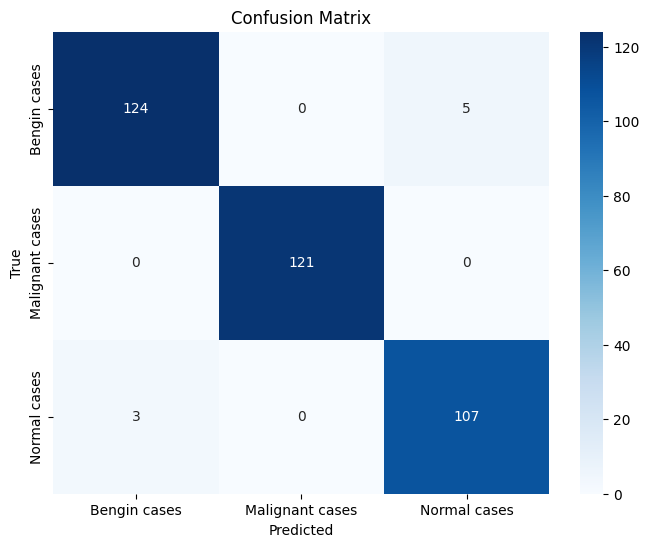

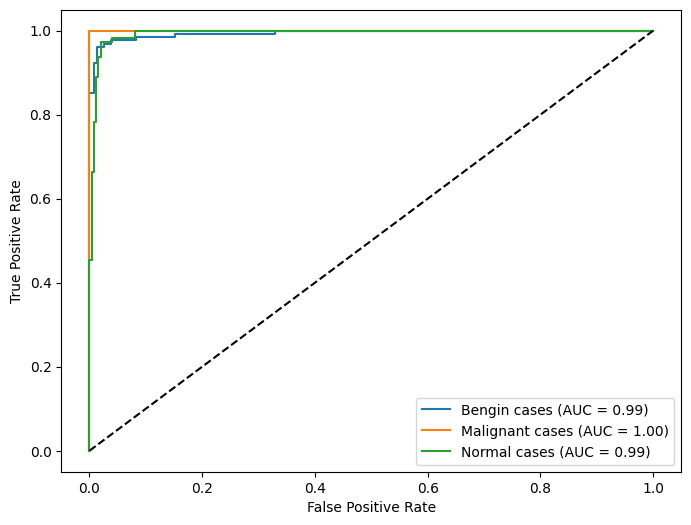

/var/folders/zs/drdvz0m57hl96dxh4_pfn3bm0000gn/T/ipykernel_13983/47468360.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")


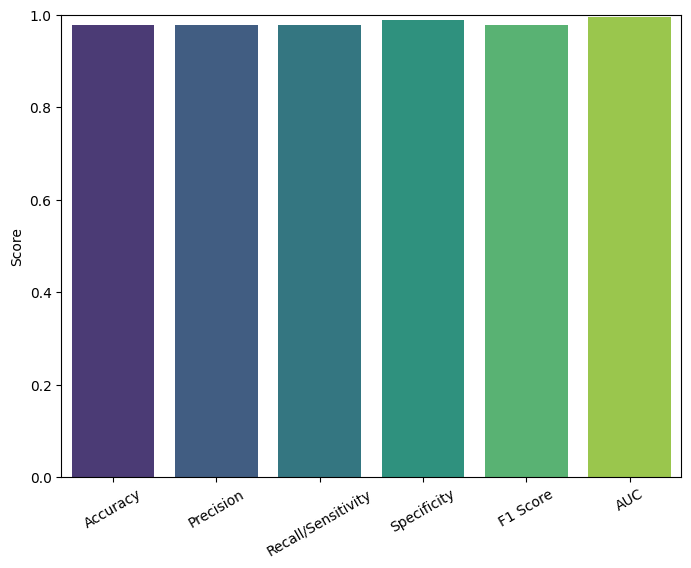

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, precision_score, recall_score, f1_score, accuracy_score)

# -------------------------
# Evaluation
# -------------------------
model.eval()
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        _, preds = torch.max(outputs, 1)
        probs = torch.softmax(outputs, dim=1)  # for AUC

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = torch.tensor(y_true)
y_pred = torch.tensor(y_pred)
y_prob = torch.tensor(y_prob)

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')   # sensitivity
f1 = f1_score(y_true, y_pred, average='macro')

# Sensitivity & Specificity (per class → macro avg)
cm = confusion_matrix(y_true, y_pred)
TP = cm.diagonal()
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

sensitivity = (TP / (TP + FN + 1e-8)).mean()
specificity = (TN / (TN + FP + 1e-8)).mean()

# AUC (multi-class)
try:
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
except:
    auc = None

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=dataset.classes))
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall/Sensitivity (macro): {recall:.4f}")
print(f"F1 Score (macro): {f1:.4f}")
print(f"Sensitivity (mean): {sensitivity:.4f}")
print(f"Specificity (mean): {specificity:.4f}")
if auc is not None:
    print(f"AUC: {auc:.4f}")


# -------------------------
# Confusion Matrix
# -------------------------
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=dataset.classes,
            yticklabels=dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# -------------------------
# ROC Curve (One-vs-Rest)
# -------------------------
if auc is not None:
    plt.figure(figsize=(8,6))
    for i, class_name in enumerate(dataset.classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc_score(y_true == i, y_prob[:, i]):.2f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("")
    plt.legend(loc="lower right")
    plt.show()


# -------------------------
# Bar Plot of Metrics
# -------------------------
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall/Sensitivity": recall,
    "Specificity": specificity,
    "F1 Score": f1
}
if auc is not None:
    metrics["AUC"] = auc

plt.figure(figsize=(8,6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")
plt.title("")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()
